# Student Performance Analysis

This project analyzes student performance data to identify factors associated with academic scores.

The analysis focuses on parental education, test preparation, gender-based performance, subject score relationships, and at-risk students.

## 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


## 2. Load Dataset

In [2]:
df= pd.read_csv("../Data/StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Data Understanding

In [4]:
df.shape

(1000, 8)

In [5]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [6]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

#### Null value checking

In [7]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

##### Duplicate values checking

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
print("Number of students:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of students: 1000
Number of columns: 8


## 4.7 Column Description

| Column | Description |
|---|---|
| gender | Gender of the student |
| race/ethnicity | Student's race/ethnicity group |
| parental level of education | Highest education level of the student's parent(s) |
| lunch | Type of lunch received by the student |
| test preparation course | Whether the student completed the test preparation course |
| math score | Student's mathematics score |
| reading score | Student's reading score |
| writing score | Student's writing score |

## 5. Data Cleaning

In [11]:
print("Gender:")
print(df["gender"].unique())

Gender:
<StringArray>
['female', 'male']
Length: 2, dtype: str


In [12]:
print("Ethnicity:")
print(df["race/ethnicity"].unique())

Ethnicity:
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str


In [13]:
print("\nParental Level of Education:")
print(df["parental level of education"].unique())

print("\nLunch:")
print(df["lunch"].unique())

print("\nTest Preparation Course:")
print(df["test preparation course"].unique())


Parental Level of Education:
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

Lunch:
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

Test Preparation Course:
<StringArray>
['none', 'completed']
Length: 2, dtype: str


In [14]:
print("Maths Score:")
print(df["math score"].min())
print(df["math score"].max())


Maths Score:
0
100


In [15]:
print("Reading Score:")
print(df["reading score"].min())
print(df["reading score"].max())

Reading Score:
17
100


In [16]:
print("writing Score:")
print(df["writing score"].min())
print(df["writing score"].max())

writing Score:
10
100


### Data Cleaning Decisions

Based on the data-quality checks:

- No missing values were found in the dataset.
- No duplicate records were identified.
- The categorical values were checked for consistency.
- The mathematics, reading, and writing scores were checked to ensure they fall within the expected range of 0 to 100.
- The existing data types are appropriate for the analysis.

Therefore, no major data-cleaning transformations were required before performing the analysis.

### 5-Line Dataset Summary

1. The dataset contains **1,000 student records** and **8 columns**.
2. It contains information about students' gender, race/ethnicity, parental education, lunch type, test preparation, and subject scores.
3. The average mathematics score is **66.089**.
4. The average reading score is **69.169**, which is higher than the average mathematics score.
5. The average writing score is **68.054**, which is also higher than the average mathematics score.
6.  Datasets do not have any null values and duplicate data 


### 6. Factor Analysis

#### Q1.Does parental education level affect scores?

In [17]:
df["parental level of education"].value_counts()


parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [18]:
df.groupby("parental level of education")["math score"].mean()

parental level of education
associate's degree    67.882883
bachelor's degree     69.389831
high school           62.137755
master's degree       69.745763
some college          67.128319
some high school      63.497207
Name: math score, dtype: float64

In [19]:
df.groupby("parental level of education")["reading score"].mean()

parental level of education
associate's degree    70.927928
bachelor's degree     73.000000
high school           64.704082
master's degree       75.372881
some college          69.460177
some high school      66.938547
Name: reading score, dtype: float64

In [20]:
df.groupby("parental level of education")["writing score"].mean()

parental level of education
associate's degree    69.896396
bachelor's degree     73.381356
high school           62.448980
master's degree       75.677966
some college          68.840708
some high school      64.888268
Name: writing score, dtype: float64

In [21]:
df.groupby("parental level of education")[
    ["math score", "reading score", "writing score"]
].mean()

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


### Answer 1

The average scores vary across different parental education levels. Students whose parents have a **master's degree** have the highest average scores in mathematics (69.75), reading (75.37), and writing (75.68). Students whose parents have a **high school education** have the lowest average scores in mathematics (62.14), reading (64.70), and writing (62.45).


### Q2.Do students who complete test preparation score higher?

In [22]:
df["test preparation course"].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

In [23]:
df.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


### Answer 2

Students who completed the test preparation course achieved higher average scores than students who did not complete the course in all three subjects.

- Mathematics: 69.70 for completed vs 64.08 for none.
- Reading: 73.89 for completed vs 66.53 for none.
- Writing: 74.42 for completed vs 64.50 for none.

### Q3.What is the correlation between reading, writing, and math scores?

In [24]:
df[["math score", "reading score", "writing score"]].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


### Answer 3

There is a strong positive correlation between all three subject scores.

- Math and Reading: **0.818**
- Math and Writing: **0.803**
- Reading and Writing: **0.955**


### Q4.Which gender performs better in which subject?

In [25]:
df.groupby("gender")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


### Answer 4

Performance differs by gender across the three subjects. Male students have a higher average mathematics score (68.73) compared with female students (63.63). Female students have higher average reading (72.61) and writing (72.47) scores compared with male students (65.47 and 63.31 respectively).

### Q5.What is the distribution of total scores?

In [26]:
df["total score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

df["total score"].head()

0    218
1    247
2    278
3    148
4    229
Name: total score, dtype: int64

In [27]:
df["total score"].describe()

count    1000.000000
mean      203.312000
std        42.771978
min        27.000000
25%       175.000000
50%       205.000000
75%       233.000000
max       300.000000
Name: total score, dtype: float64

### Answer 5

The total scores range from **27 to 300**, with an average score of **203.31** and a median of **205**. The middle 50% of students have total scores between **175 and 233**. The mean and median are relatively close, indicating that the overall distribution is centered around approximately 200 points.

# 8. Visualizations

## 8.1 Box Plot — Math Scores by Parental Education

C:\Users\Pc\AppData\Local\Temp\ipykernel_25176\990233050.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="parental level of education",y="math score",data=df,palette="Set1")


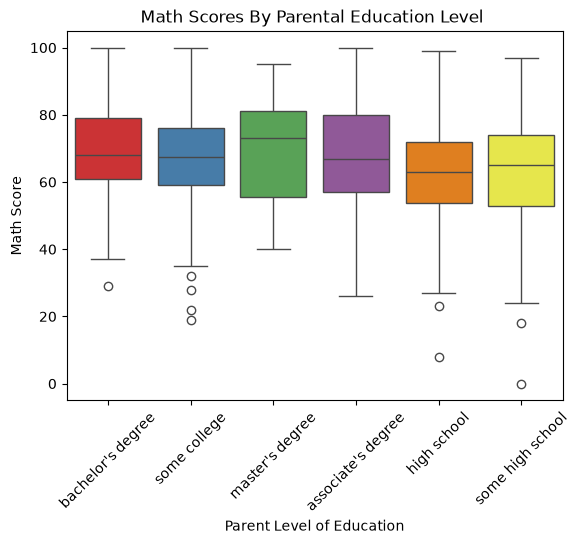

In [28]:
sns.boxplot(x="parental level of education",y="math score",data=df,palette="Set1")
plt.title("Math Scores By Parental Education Level ")
plt.xlabel("Parent Level of Education")
plt.ylabel("Math Score")
plt.xticks(rotation=45)
plt.show()

## 8.2 Bar Chart — Test Preparation vs Average Scores

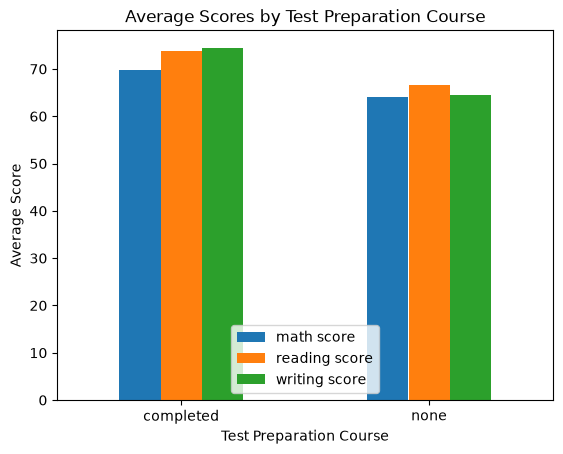

In [29]:
average_scores = df.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean()

average_scores.plot(kind="bar")

plt.title("Average Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()

## 8.3 Correlation Heatmap — Subject Scores

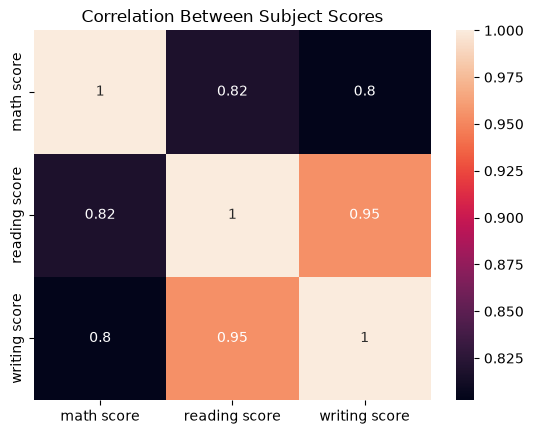

In [30]:
correlation = df[["math score", "reading score", "writing score"]].corr()

sns.heatmap(correlation, annot=True)

plt.title("Correlation Between Subject Scores")
plt.show()

## 8.4 Grouped Bar Chart — Gender vs Subject Performance

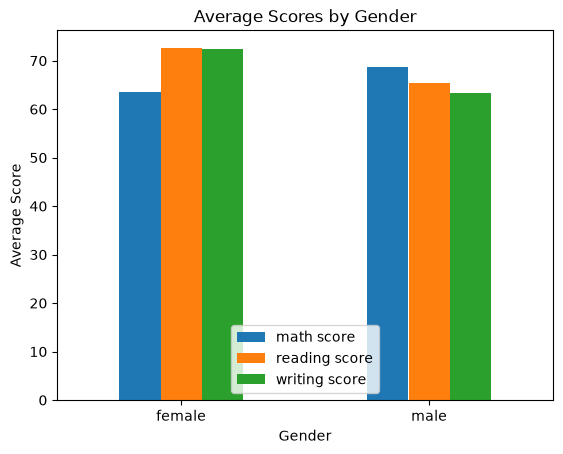

In [31]:
gender_scores = df.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean()

gender_scores.plot(kind="bar")

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()

## 8.5 Histogram — Total Score Distribution

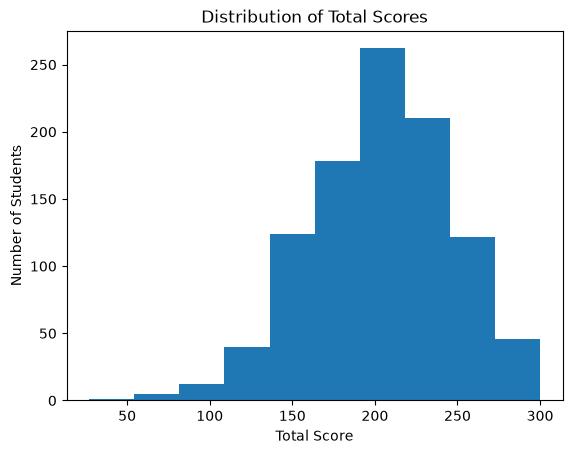

In [32]:
plt.hist(df["total score"])

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")
plt.show()

## 8.6 Scatter Plot — Reading Score vs Math Score

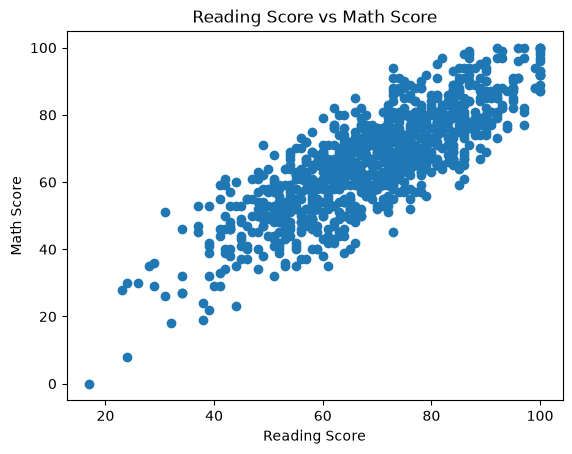

In [33]:
plt.scatter(df["reading score"], df["math score"])

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.show()

# 9. At-Risk Student Segmentation

## 9.1 Define At-Risk Students

For this analysis, a student is considered **at-risk** if their score is below 50 in at least one of the three subjects: Mathematics, Reading, or Writing.

In [34]:
df["at_risk"] = (
    (df["math score"] < 50) |
    (df["reading score"] < 50) |
    (df["writing score"] < 50)
)

df["at_risk"].value_counts()

at_risk
False    812
True     188
Name: count, dtype: int64

##### 9.2 At-Risk Student Percentage
The percentage of at-risk students is calculated to understand the overall proportion of students who may require additional academic support.

In [35]:
at_risk_count = df["at_risk"].sum()
total_students = len(df)

at_risk_percentage = (at_risk_count / total_students) * 100

print("At-Risk Students:", at_risk_count)
print("Total Students:", total_students)
print("At-Risk Percentage:", at_risk_percentage)

At-Risk Students: 188
Total Students: 1000
At-Risk Percentage: 18.8


#### 9.3 At-Risk Percentage by Gender

In [36]:
df.groupby("gender")["at_risk"].mean() * 100

gender
female    17.181467
male      20.539419
Name: at_risk, dtype: float64

### 9.4 At-Risk Percentage by Parental Education

In [37]:
df.groupby("parental level of education")["at_risk"].mean() * 100

parental level of education
associate's degree    14.864865
bachelor's degree     13.559322
high school           25.000000
master's degree       10.169492
some college          16.814159
some high school      25.698324
Name: at_risk, dtype: float64

### 9.5 At-Risk Percentage by Test Preparation

In [38]:
df.groupby("test preparation course")["at_risk"].mean() * 100

test preparation course
completed    10.055866
none         23.676012
Name: at_risk, dtype: float64

## 9.6 At-Risk Segmentation Table by Gender

In [39]:
gender_risk = df.groupby("gender")["at_risk"].agg(["sum", "count"])

gender_risk["percentage"] = (
    gender_risk["sum"] / gender_risk["count"]
) * 100

gender_risk

,sum,count,percentage
gender,,,
female,89,518,17.181467
male,99,482,20.539419


In [40]:
df.groupby("parental level of education")["at_risk"].mean().sort_values(ascending=False) * 100

parental level of education
some high school      25.698324
high school           25.000000
some college          16.814159
associate's degree    14.864865
bachelor's degree     13.559322
master's degree       10.169492
Name: at_risk, dtype: float64

In [41]:
risk_by_education = df.groupby(
    "parental level of education"
)["at_risk"].mean() * 100

risk_by_education.idxmax()

'some high school'

In [42]:
risk_by_preparation = df.groupby(
    "test preparation course"
)["at_risk"].mean() * 100

risk_by_preparation.idxmax()

'none'

## 9.10 At-Risk Student Findings

Using the threshold of scoring below 50 in at least one subject, **188 out of 1,000 students (18.8%)** are classified as at-risk.

The at-risk percentage is **17.18% for female students** and **20.54% for male students**, so the male group has a higher at-risk percentage.


These results help identify student groups that may benefit from targeted academic intervention.

# Principal's Report

## Executive Summary

The analysis shows that student performance varies based on different factors. Students who completed test preparation performed better. Overall, **18.8% of students are at risk** and may need extra support.

## 5 Key Findings

1. Students with more educated parents generally scored higher.
2. Students who completed test preparation had higher scores.
3. Reading and writing scores have a strong relationship.
4. Male students scored higher in Math, while female students scored higher in Reading and Writing.
5. **188 out of 1,000 students** are at risk.

## 3 Actionable Recommendations

1. Provide **extra classes** for at-risk students.
2. Encourage students to **complete test preparation courses**.
3. Conduct **regular assessments** to identify and support weak students early.